<a href="https://colab.research.google.com/github/ramyamurugesh-eng/Engineering-Multimodal-AI/blob/main/Engineering_Multimodal_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective

In this demo, we will demonstrate how a multimodal AI system processes an image.

Workflow:
1. Upload an image
2. Preprocess the image
3. Generate an image embedding using a Vision Transformer (CLIP)
4. Generate text embeddings
5. Compare image and text embeddings
6. Find the best semantic match

# Step 1: Install Required Libraries

We install OpenCLIP and supporting libraries required for image preprocessing and embedding generation.

In [ ]:
# Install the required Python libraries.
# - open_clip_torch: Provides the OpenCLIP models and utilities.
# - pillow: Used for opening and processing images.
# - matplotlib: Used for displaying images and plots.
!pip -q install open_clip_torch pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


# Step 2: Import Libraries

Import the required Python libraries for image processing, visualization, and the CLIP model.

In [ ]:
# Import the PyTorch library for deep learning operations.
import torch

# Import the OpenCLIP library.
import open_clip


# Import the Image class from Pillow for loading image files.
from PIL import Image

# Import Matplotlib's pyplot module for displaying images.
import matplotlib.pyplot as plt

# Step 3: Load the Vision Encoder (CLIP)

Load the pretrained CLIP Vision Transformer model.

The model has already learned rich visual representations from millions of image–text pairs.

**CLIP - Contrastive Language-Image Pretraining**

CLIP is a multimodal model developed by OpenAI that learns a shared embedding space for images and text. It can compare an image directly with natural language descriptions without task-specific training.

In [ ]:
# Create the CLIP model and the image preprocessing pipeline.
# "ViT-B-32" is the model architecture.
# "laion2b_s34b_b79k" specifies the pretrained weights.
model,_,preprocess = open_clip.create_model_and_transforms("ViT-B-32",pretrained="laion2b_s34b_b79k")

# Load the tokenizer for converting text prompts into tokens
# that the CLIP model can understand.
tokenizer=open_clip.get_tokenizer("ViT-B-32")

# Check if a CUDA-enabled GPU is available.
# If yes, use the GPU for faster inference; otherwise, use the CPU.
device="cuda" if torch.cuda.is_available() else "cpu"


# Move the model to the selected device (GPU or CPU).
model = model.to(device)

# Display the device being used.
print("Running on: ",device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Running on:  cuda


ViT- Vision Transformer

B- Base model size

32 - Image is divided into 32x32 pixel patches

LAION-2B - A large-scale dataset containing over 2 billion image-text pairs


In [ ]:
# Import the files module from Google Colab.
# This module allows users to upload files from their local computer.
from google.colab import files

# Open a file upload dialog.
# The uploaded file(s) are stored in a dictionary named 'uploaded',
# where:
#   - Key   = filename
#   - Value = file content (in binary format)
uploaded = files.upload()

Saving Cat with glasses.jpg to Cat with glasses.jpg


(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

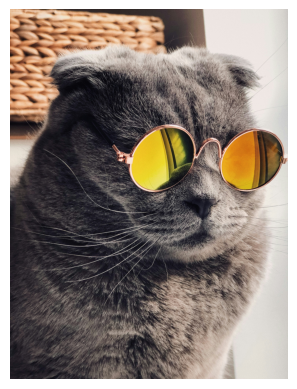

In [ ]:
# Get the name of the uploaded image file.
image_path=list(uploaded.keys())[0]

# Open the image using the Pillow library.
image=Image.open(image_path)

# Display the image.
plt.imshow(image)


# Hide the x-axis and y-axis.
plt.axis("off")

In [ ]:
# Preprocess the image before passing it to the CLIP model.
# The preprocess pipeline resizes, crops, converts the image to a tensor,
# and normalizes pixel values as required by the model.
image_input=preprocess(image).unsqueeze(0).to(device)

# Display the shape of the image tensor.
print(image_input.shape)

torch.Size([1, 3, 224, 224])


In [ ]:
# Define a list of text descriptions (prompts) to compare with the image.
# The tokenizer converts these text prompts into tokens that the CLIP model can understand,
# and moves them to the selected device (CPU or GPU).
text=tokenizer(["a happy dog on the beach","a dog","a sleeping cat","a cat with glasses",
                "a flying bird","a red sports car","a bat","a laptop on a desk",
                "a book"]).to(device)

In [ ]:
# Disable gradient calculation since we are only performing inference,
# which makes the execution faster and uses less memory.
with torch.no_grad():

  # Generate feature (embedding) vectors for the input image.
  image_features=model.encode_image(image_input)

  # Generate feature (embedding) vectors for the text prompts.
  text_features=model.encode_text(text)

  # Normalize the image feature vectors to unit length.
  image_features/=image_features.norm(dim=-1,keepdim=True)

  # Normalize the text feature vectors to unit length.
  text_features/=text_features.norm(dim=-1,keepdim=True)

  # Compute similarity scores between the image and each text prompt.
  # Apply Softmax to convert the scores into probabilities.
  similarity=(100.0 * image_features @ text_features.T).softmax(dim=-1)

  # Display the similarity scores.
  print(similarity)


tensor([[8.0162e-10, 4.1822e-07, 1.7124e-06, 1.0000e+00, 2.8442e-11, 6.9643e-13,
         1.7469e-08, 7.9065e-13, 1.8626e-09]], device='cuda:0')


In [ ]:
# Define readable labels corresponding to the text prompts.
labels=["Happy Dog on the Beach","Dog",'Sleeping Cat',"Cat with Glasses","Flying Bird","Sports Car",
        "Bat","Laptop","Book"]

# Move the similarity scores from the GPU to the CPU
# and convert them into a NumPy array.
scores=similarity[0].cpu().numpy()

# Display the prediction results.
print("Prediction Results: \n")

# Print each label along with its prediction probability.
for label,score in zip(labels,scores):
  print(f"{label:10s}:{score:.2%}")

# Find the label with the highest probability.
best=labels[scores.argmax()]

# Display the best matching label
print("\nBest Match: ",best)

Prediction Results: 

Happy Dog on the Beach:0.00%
Dog       :0.00%
Sleeping Cat:0.00%
Cat with Glasses:100.00%
Flying Bird:0.00%
Sports Car:0.00%
Bat       :0.00%
Laptop    :0.00%
Book      :0.00%

Best Match:  Cat with Glasses
